# Polynomial Linear Regression: 
### Implement BGD, SGD, mini-batch; MSE loss; vectorized NumPy


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate Data
X = np.linspace(-3, 3, 50).reshape(-1,1)
y = 0.5 * X**3 - X**2 + 2*X + 3 + np.random.randn(50, 1) * 3

In [2]:
def polynomial_features(X, degree):
    n = X.shape[0]
    X_poly = np.ones((n, 1))

    for d in range(1, degree + 1):
        X_poly = np.hstack((X_poly, X**d))

    return X_poly

In [3]:
def normal_equation(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

In [4]:
def normal_equation_pinv(X, y):
    return np.linalg.pinv(X)@y

In [5]:
# Train Polynomial model
degree = 3

X_poly = polynomial_features(X, degree)
w = normal_equation_pinv(X_poly, y)

In [6]:
def predict(X, w, degree):
    X_poly = polynomial_features(X, degree)
    return X_poly @ w

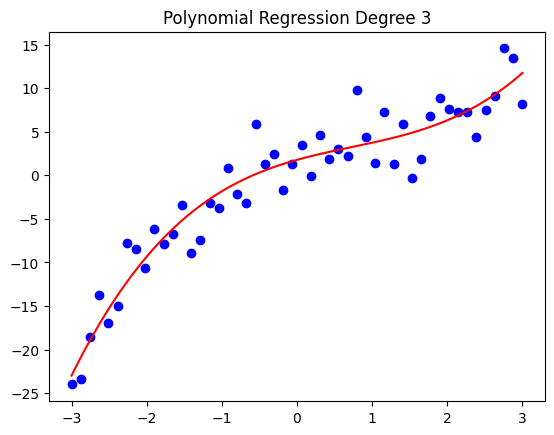

In [7]:
X_test = np.linspace(-3, 3, 200).reshape(-1,1)
y_pred = predict(X_test, w, degree)

plt.scatter(X, y, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.title(f'Polynomial Regression Degree {degree}')
plt.show()